In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rc('figure', facecolor='w')
plt.rc('font', size=11)

In [2]:
def read_data(filename):
    data = scipy.io.loadmat(filename, squeeze_me=True)
    return {k: v for k, v in data.items() if hasattr(v, 'shape')}


def merge_dicts(list_of_dicts):
    keys = list_of_dicts[0].keys()
    return {k: np.array([_[k] for _ in list_of_dicts]) for k in keys}

enzyme_data = merge_dicts([read_data(f'CHO/alpha/{i}.mat') for i in range(1, 49)])

In [3]:
A_thole_inv = np.linalg.inv(enzyme_data['A_thole'])
A_thole_inv_mean = np.mean(A_thole_inv, axis=1)
atomic_alpha_emle = np.sum(A_thole_inv_mean.reshape(48, 24, 3, 24, 3), axis=3)
atomic_iso_emle = np.trace(atomic_alpha_emle, axis1=2, axis2=3) / 3

In [4]:
def parse_polaratom_frame(window, frame):
    return np.loadtxt(f'CHO/alpha/polaratom/{window}_{frame}.polaratom', dtype=str)[:, -1].astype(float)

def parse_polaratom_window(window):
    return np.mean([parse_polaratom_frame(window, i+1) for i in range(500)], axis=0)

polaratom = np.array([parse_polaratom_window(i+1) for i in range(48)])

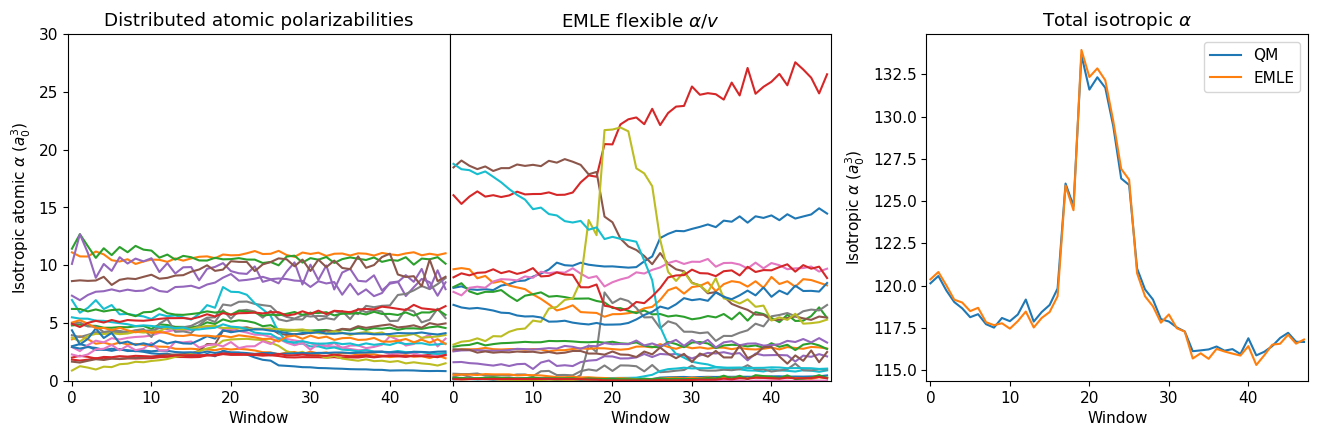

In [5]:
idx = np.arange(24)
fig, axs = plt.subplots(1, 4, figsize=(16, 4.5), 
                        gridspec_kw={'width_ratios': [1, 1, 0.25, 1], 'wspace': 0})

for ax in axs[:2]:
    ax.set_xlim(-0.5, 47.5)
    ax.set_ylim(0, 30)

for i in idx:
    axs[0].plot(polaratom[:,i], label=str(i))
    axs[1].plot(atomic_iso_emle[:,i], label=str(i))
for ax in axs:
    ax.set_xlabel('Window')
    ax.set_ylabel('Isotropic atomic $\\alpha$ ($a_0^3)$')
axs[0].set_title('Distributed atomic polarizabilities')

axs[1].set_title('EMLE flexible $\\alpha / v$')
axs[1].yaxis.set_visible(False)

axs[2].axis('off')

axs[3].set_xlim([-0.5, 47.5])
axs[3].plot(np.sum(polaratom, axis=1), label='QM')
axs[3].plot(np.sum(atomic_iso_emle, axis=1), label='EMLE')
axs[3].set_xlabel('Window')
axs[3].set_ylabel('Isotropic $\\alpha$ ($a_0^3)$')
axs[3].set_title('Total isotropic $\\alpha$')
axs[3].legend()
plt.savefig('FigS4.png', dpi=300, bbox_inches='tight')
plt.show()